In [ ]:
#Synthetic Data Creation

import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

data = {
    "order_id": range(1, n+1),
    "restaurant_prep_time": np.random.randint(10, 45, n),
    "delivery_time": np.random.randint(15, 60, n),
    "distance_km": np.round(np.random.uniform(1, 12, n), 1),
    "weather": np.random.choice(["Clear", "Rain"], n, p=[0.7, 0.3]),
    "peak_hour": np.random.choice(["Yes", "No"], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Define delay condition
df["delayed"] = np.where(
    (df["restaurant_prep_time"] > 30) |
    (df["delivery_time"] > 45) |
    ((df["weather"] == "Rain") & (df["delivery_time"] > 40)),
    1,
    0
)

df.head()


,order_id,restaurant_prep_time,delivery_time,distance_km,weather,peak_hour,delayed
0,1,38,33,2.8,Clear,No,1
1,2,24,34,1.4,Clear,Yes,0
2,3,17,32,4.4,Clear,Yes,0
3,4,30,55,9.6,Clear,Yes,1
4,5,28,28,4.1,Clear,Yes,0


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              500 non-null    int64  
 1   restaurant_prep_time  500 non-null    int32  
 2   delivery_time         500 non-null    int32  
 3   distance_km           500 non-null    float64
 4   weather               500 non-null    object 
 5   peak_hour             500 non-null    object 
 6   delayed               500 non-null    int64  
dtypes: float64(1), int32(2), int64(2), object(2)
memory usage: 23.6+ KB


In [4]:
df.describe()

,order_id,restaurant_prep_time,delivery_time,distance_km,delayed
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,27.846000,36.420000,6.671400,0.616000
std,144.481833,10.427644,12.997441,3.222168,0.486845
min,1.000000,10.000000,15.000000,1.000000,0.000000
25%,125.750000,18.000000,25.000000,3.975000,0.000000
50%,250.500000,29.000000,37.000000,6.800000,1.000000
75%,375.250000,37.000000,48.000000,9.500000,1.000000
max,500.000000,44.000000,59.000000,12.000000,1.000000


In [5]:
df.isnull().sum()

order_id                0
restaurant_prep_time    0
delivery_time           0
distance_km             0
weather                 0
peak_hour               0
delayed                 0
dtype: int64

,order_id,restaurant_prep_time,delivery_time,distance_km,weather,peak_hour,delayed


In [7]:
#How many orders are delayed

df['delayed'].value_counts(normalize = True)* 100

delayed
1    61.6
0    38.4
Name: proportion, dtype: float64

In [8]:
#Does restaurant prep time cause delay?

df.groupby('delayed')['restaurant_prep_time'].mean()

delayed
0    19.489583
1    33.055195
Name: restaurant_prep_time, dtype: float64

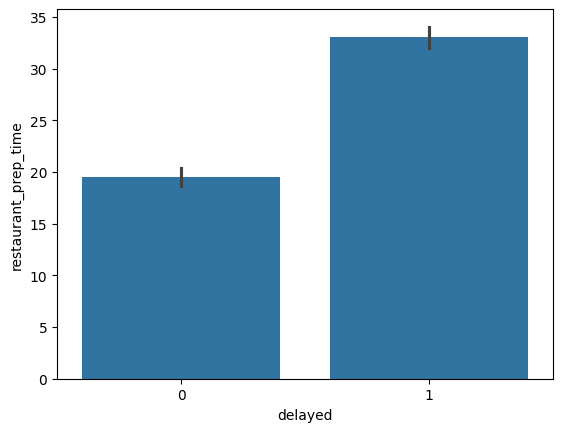

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x ='delayed', y ='restaurant_prep_time', data = df)
plt.show()

In [10]:
# Does distance matter?

df.groupby("delayed")["distance_km"].mean()


delayed
0    6.828646
1    6.573377
Name: distance_km, dtype: float64

In [11]:
#weather and peak hours 

pd.crosstab(df['weather'], df['delayed'], normalize= 'index') * 100

#pd.crosstab(df["peak_hour"], df["delayed"], normalize="index") * 100

delayed,0,1
weather,,
Clear,39.784946,60.215054
Rain,34.375000,65.625000


In [12]:
pd.crosstab(df["peak_hour"], df["delayed"], normalize="index") * 100

delayed,0,1
peak_hour,,
No,43.842365,56.157635
Yes,34.680135,65.319865


In [13]:
# order prep time over 30 mins 

df['prep_over_30'] = df['restaurant_prep_time'] > 30
pd.crosstab(df['prep_over_30'], df['delayed'], normalize='index') *100

delayed,0,1
prep_over_30,,
False,71.111111,28.888889
True,0.000000,100.000000


In [14]:
df_under_30 = df[df["restaurant_prep_time"] <= 30]

pd.crosstab(df_under_30["weather"], df_under_30["delayed"], normalize="index") * 100


delayed,0,1
weather,,
Clear,75.126904,24.873096
Rain,60.273973,39.726027


In [15]:
pd.crosstab(df_under_30["peak_hour"], df_under_30["delayed"], normalize="index") * 100


delayed,0,1
peak_hour,,
No,76.068376,23.931624
Yes,67.320261,32.679739
